## With NYC dataset

In [33]:
import pandas as pd
import numpy as np

df = pd.read_csv('datasets/nyc.csv')
df.head()

,Price,Food,Decor,Service,East
0,36,23,14,21,1
1,49,20,14,16,0
2,58,20,15,20,1
3,44,18,18,20,0
4,40,20,15,15,0


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Price    168 non-null    int64
 1   Food     168 non-null    int64
 2   Decor    168 non-null    int64
 3   Service  168 non-null    int64
 4   East     168 non-null    int64
dtypes: int64(5)
memory usage: 6.7 KB


In [35]:
df['East'].value_counts()

East
0    85
1    83
Name: count, dtype: int64

In [36]:
df.shape

(168, 5)

In [37]:
df.drop_duplicates(keep='first', inplace=True)
# keep='first' -> Keeps the first occurrence of each duplicate and removes the rest.
# inplace=True  -> Makes the change directly to df, without needing to assign it to a new variable.
df

,Price,Food,Decor,Service,East
0,36,23,14,21,1
1,49,20,14,16,0
2,58,20,15,20,1
3,44,18,18,20,0
4,40,20,15,15,0
...,...,...,...,...,...
163,53,21,18,16,0
164,34,21,20,21,1
165,32,20,16,19,1
166,41,21,12,19,0


In [38]:
df.isnull().sum()

Price      0
Food       0
Decor      0
Service    0
East       0
dtype: int64

In [39]:
df.describe()

,Price,Food,Decor,Service,East
count,168.000000,168.000000,168.000000,168.000000,168.000000
mean,45.059524,21.434524,15.785714,17.839286,0.494048
std,9.031351,2.281506,2.633599,1.949452,0.501459
min,30.000000,18.000000,12.000000,15.000000,0.000000
25%,37.000000,20.000000,14.000000,16.000000,0.000000
50%,44.500000,21.000000,16.000000,18.000000,0.000000
75%,53.000000,23.000000,18.000000,19.000000,1.000000
max,59.000000,25.000000,20.000000,21.000000,1.000000


<Axes: ylabel='Price'>

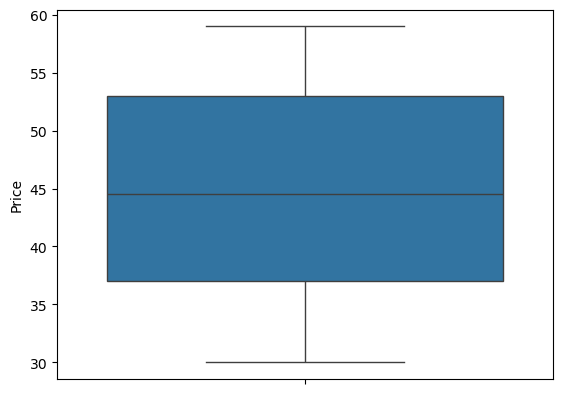

In [40]:
import seaborn as sns

sns.boxplot(y = df['Price']) 

In [41]:
 #  box plot (also known as a box-and-whisker plot)
'''
Box plots provide a visual summary of the distribution of data, including:

Minimum

1st Quartile (Q1)

Median (Q2)

3rd Quartile (Q3)

Maximum

(Optionally) Outliers
'''

# Try to add some outliers data (very large or very small) in the column and find out the output

'\nBox plots provide a visual summary of the distribution of data, including:\n\nMinimum\n\n1st Quartile (Q1)\n\nMedian (Q2)\n\n3rd Quartile (Q3)\n\nMaximum\n\n(Optionally) Outliers\n'

In [42]:
df['Price'].unique()

array([36, 49, 58, 44, 40, 37, 50, 55, 48, 52, 53, 33, 32, 51, 31, 41, 59,
       35, 57, 30, 54, 46, 56, 39, 45, 34, 38, 47, 43, 42], dtype=int64)

<Axes: ylabel='Food'>

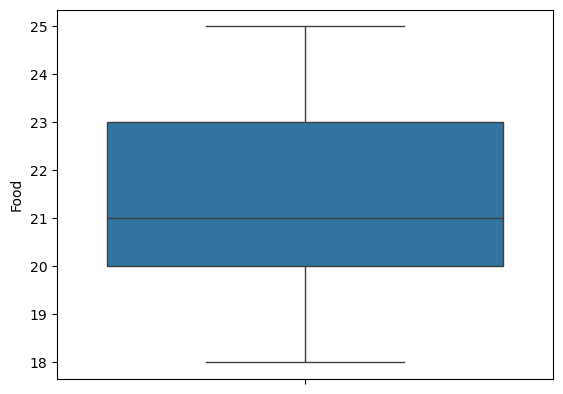

In [43]:
sns.boxplot(y = df['Food'])

<Axes: ylabel='Decor'>

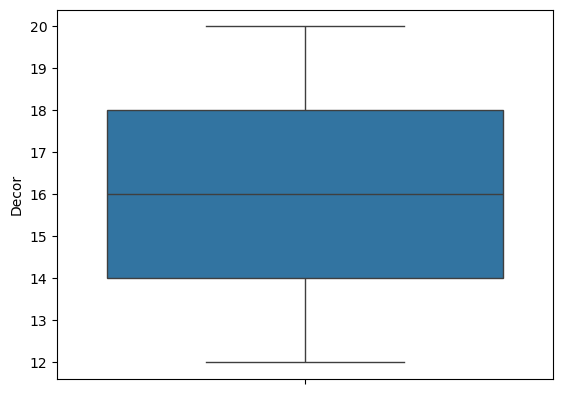

In [44]:
sns.boxplot(y = df['Decor'])

In [45]:
df['Decor'].unique()

array([14, 15, 18, 20, 12, 19, 13, 16, 17], dtype=int64)

<Axes: ylabel='Service'>

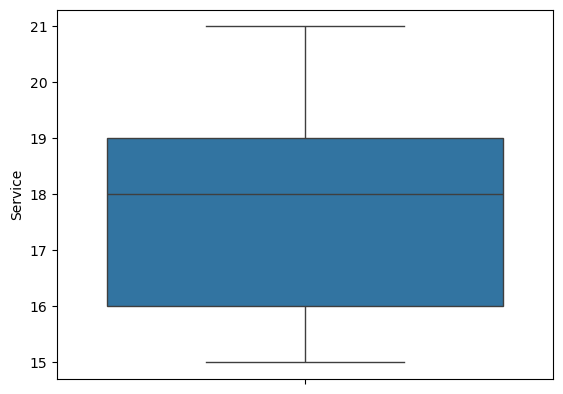

In [46]:
sns.boxplot(y = df['Service'])

In [47]:
df.corr()

,Price,Food,Decor,Service,East
Price,1.000000,0.000481,-0.004747,-0.037886,-0.130819
Food,0.000481,1.000000,0.118237,0.115423,0.083400
Decor,-0.004747,0.118237,1.000000,-0.031241,0.048904
Service,-0.037886,0.115423,-0.031241,1.000000,0.032705
East,-0.130819,0.083400,0.048904,0.032705,1.000000


In [48]:

'''
1 ->	Perfect positive correlation (as one increases, so does the other)
0 ->	No linear correlation
-1 ->	Perfect negative correlation (as one increases, the other decreases)
'''

'\n1 ->\tPerfect positive correlation (as one increases, so does the other)\n0 ->\tNo linear correlation\n-1 ->\tPerfect negative correlation (as one increases, the other decreases)\n'

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error

In [50]:
X = df[['Food']]
y = df['Price']


#y = np.log(y)            Price is limited to a range so we need not to take logarithm

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [52]:
#Finding the mean for test data value
base_pred = np.mean(y_test)
print(base_pred)

43.78431372549019


In [53]:
#Repeating same value tilllength of test data

base_pred = np.repeat(base_pred, len(y_test))
base_pred

array([43.78431373, 43.78431373, 43.78431373, 43.78431373, 43.78431373,
       43.78431373, 43.78431373, 43.78431373, 43.78431373, 43.78431373,
       43.78431373, 43.78431373, 43.78431373, 43.78431373, 43.78431373,
       43.78431373, 43.78431373, 43.78431373, 43.78431373, 43.78431373,
       43.78431373, 43.78431373, 43.78431373, 43.78431373, 43.78431373,
       43.78431373, 43.78431373, 43.78431373, 43.78431373, 43.78431373,
       43.78431373, 43.78431373, 43.78431373, 43.78431373, 43.78431373,
       43.78431373, 43.78431373, 43.78431373, 43.78431373, 43.78431373,
       43.78431373, 43.78431373, 43.78431373, 43.78431373, 43.78431373,
       43.78431373, 43.78431373, 43.78431373, 43.78431373, 43.78431373,
       43.78431373])

In [54]:
#Finding the RMSE

base_root_mean_square_error = np.sqrt(mean_squared_error(y_test, base_pred))
base_root_mean_square_error

9.31857458907555

In [55]:
ln1 = LinearRegression(fit_intercept=True)

model1 = ln1.fit(X_train, y_train)

In [56]:
#finding the mean for test data value

pred1 = ln1.predict(X_test)
pred1

array([45.5422764 , 45.60251345, 45.6627505 , 45.60251345, 45.60251345,
       45.6627505 , 45.72298755, 45.6627505 , 45.72298755, 45.84346165,
       45.6627505 , 45.5422764 , 45.60251345, 45.4218023 , 45.4218023 ,
       45.5422764 , 45.5422764 , 45.84346165, 45.5422764 , 45.84346165,
       45.72298755, 45.60251345, 45.72298755, 45.60251345, 45.72298755,
       45.7832246 , 45.84346165, 45.7832246 , 45.4218023 , 45.72298755,
       45.5422764 , 45.7832246 , 45.7832246 , 45.6627505 , 45.72298755,
       45.7832246 , 45.5422764 , 45.5422764 , 45.5422764 , 45.7832246 ,
       45.6627505 , 45.72298755, 45.7832246 , 45.5422764 , 45.7832246 ,
       45.7832246 , 45.6627505 , 45.72298755, 45.60251345, 45.4218023 ,
       45.72298755])

In [57]:
#finding the MSE and RMSE

ln1_mse = mean_squared_error(y_test, pred1)

ln1_rmse = np.sqrt(ln1_mse)
print(ln1_rmse)

9.504876783734089


In [58]:
#finding the R-squared

r2_ln1_test1 = ln1.score(X_test, y_test)

print(r2_ln1_test1)

-0.04038482969533752


In [59]:
cols = df.columns
cols

Index(['Price', 'Food', 'Decor', 'Service', 'East'], dtype='object')

In [60]:
X = df[[ 'Food', 'Decor', 'Service', 'East']]
y = df['Price']

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [62]:
ln2 = LinearRegression(fit_intercept=True)

model2 = ln2.fit(X_train, y_train)

In [63]:
pred2 = ln2.predict(X_test)
pred2

array([44.89961834, 45.80642033, 42.15559141, 47.13526195, 49.17405225,
       45.44301622, 44.41399896, 43.16360459, 45.5944045 , 44.62578261,
       44.27458882, 44.23519753, 47.41062536, 41.0460317 , 42.82143674,
       44.04004123, 44.9678473 , 45.64458159, 48.17506501, 48.00420033,
       44.58639132, 44.46679292, 47.62121666, 49.09384514, 45.19336895,
       44.31398011, 47.31701558, 46.35277042, 45.02064126, 46.7736177 ,
       43.708427  , 45.49319331, 44.98918672, 48.98184816, 42.22677258,
       44.49715827, 46.74325234, 44.89961834, 47.24725893, 48.27661153,
       48.82143394, 42.57036495, 47.53198361, 44.89961834, 48.19640442,
       45.4129862 , 48.47784157, 46.36179636, 49.09384514, 44.50465653,
       43.92197051])

In [64]:
#finding the MSE and RMSE

ln2_mse = mean_squared_error(y_test, pred2)

ln2_rmse = np.sqrt(ln2_mse)
print(ln2_rmse)

10.251801891769501


In [65]:
#finding the R-squared

r2_ln2_test2 = ln2.score(X_test, y_test)

print(r2_ln2_test2)

-0.21032342475453292


## With own dataset

In [67]:
df = pd.read_csv("datasets/outliers.csv")
df

,HouseSize,DistanceToCity,Location,Price
0,NaN,22.92,B,20.74
1,48.6,27.90,B,19.35
2,NaN,28.29,A,23.30
3,65.2,25.99,A,25.37
4,47.7,29.19,A,19.66
...,...,...,...,...
95,115.4,81.93,C,45.12
96,133.0,75.58,C,50.43
97,132.6,80.77,B,50.44
98,130.1,80.29,C,52.66
